# N11 Tape Hessian Regularization vs Max `dλ`

Runs the regularization ablation for tape using the `2d_tape_ICNN.ipynb` configuration. Each model is trained with a fixed conservative continuation step and then evaluated with increasingly large inference steps using strict convergence checks.

In [ ]:
import json
import os
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

jax.config.update("jax_enable_x64", True)
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

from properties import TapeN11Properties
from run_architectures import SweepConfig, subset_tape_tube_candidates
from run_hessian_reg_max_dlambda_experiment import build_arg_parser, run_experiment

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "hessian_reg_max_dlambda_outputs_n11_tape"
FIGURE_DIR = OUTPUT_DIR / "paper_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

train_file = "../experiment_data/tape_data/11_noded/n11_tape_train_dataset.npz"
valid_file = "../experiment_data/tape_data/11_noded/n11_tape_test_dataset.npz"
properties = TapeN11Properties(mass=-0.005)
K_init_chol = (0.2, 0.0, 0.1)
K_init_diag = (0.2, 0.1)

base_cfg = SweepConfig(
    der_K_diag=K_init_diag,
    der_K_chol=K_init_chol,
    hidden=(10,),
    corr_factor=0.01,
    input_mode="raw",
    only_stretching_NN=False,
    only_bending_NN=False,
    zero_reference=True,
    activation="tanh",
    mode="anisotropic",
    n_epochs=500,
    lr=5e-2,
    weight_decay=1e-5,
    seed=42,
    valid_every=10,
    max_dlambda=5e-2,
    iters=10,
    ls_steps=10,
    abs_tol=5e-4,
    rel_tol=1e-4,
    early_stop=True,
    train_fail_on_nonconvergence=False,
    prediction_fail_on_nonconvergence=False,
    hessian_reg_strength=1e-6,
    hessian_reg_probes=1,
    hessian_reg_seed=0,
    force_key=None,
    force_loss_strength=0.0,
    force_components=(0, 1, 2),
    force_sign=1.0,
    return_loss_components=False,
    early_stopping=False,
    # early_stopping_patience=250,
    # early_stopping_min_delta=1e-5,
    # early_stopping_warmup_epochs=200,
    restore_best_model=False,
    output_dir=str(OUTPUT_DIR),
    save_npz=True,
    save_model=True,
    save_plots=True,
    save_hessian_diagnostics=False,
    save_energy_landscapes=False,
    verbose=True,
    continue_on_failure=True,
)
print(f"Output dir: {OUTPUT_DIR.resolve()}")


Output dir: /Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/hessian_reg_max_dlambda_outputs_n11_tape_independent_seed_training


In [2]:
RUN_EXPERIMENT = True

# SELECTED_ARCHITECTURES = (
#     "chol_energy_baseline",
#     "chol_energy_mlp",
#     "chol_energy_icnn",
#     "brazier_diag_stiffness_baseline",
#     "brazier_diag_stiffness_mlp",
#     "brazier_diag_stiffness_icnn",
#     "brazier_chol_stiffness_baseline",
#     "brazier_chol_stiffness_mlp",
#     "brazier_chol_stiffness_icnn",
# )

# SELECTED_ARCHITECTURES = tuple(subset_tape_tube_candidates())

SELECTED_ARCHITECTURES = tuple(
    arch for arch in subset_tape_tube_candidates()
    if arch not in ["icnn_energy", "mlp_energy", "chol_stiffness_signed_mlp", "diag_stiffness_icnn", "chol_stiffness_icnn", "chol_stiffness_signed_icnn"]
)

SEEDS = (0, 1, 2,)
HESSIAN_REG_STRENGTHS = (0.0, 1e-8, 1e-6, 1e-4)
EVAL_MAX_DLAMBDA_VALUES = (1e-3, 1e-2, 1e-1, 1.0)
TRAIN_MAX_DLAMBDA_FOR_ABLATION = 5e-2

print("Architectures:", SELECTED_ARCHITECTURES)
print("Seeds:", SEEDS)
print("Hessian regularizers:", HESSIAN_REG_STRENGTHS)
print("Eval max_dlambda values:", EVAL_MAX_DLAMBDA_VALUES)
print("Train max_dlambda:", TRAIN_MAX_DLAMBDA_FOR_ABLATION)


Architectures: ('diag_energy_baseline', 'diag_energy_mlp', 'diag_energy_icnn', 'chol_energy_baseline', 'chol_energy_mlp', 'chol_energy_icnn', 'brazier_diag_stiffness_baseline', 'brazier_diag_stiffness_mlp', 'brazier_diag_stiffness_icnn', 'brazier_chol_stiffness_baseline', 'brazier_chol_stiffness_mlp', 'brazier_chol_stiffness_icnn')
Seeds: (0, 1, 2)
Hessian regularizers: (0.0, 1e-08, 1e-06, 0.0001)
Eval max_dlambda values: (0.001, 0.01, 0.1, 1.0)
Train max_dlambda: 0.05


In [3]:
def csv(values):
    return ",".join(str(v) for v in values)

argv = [
    "--properties-class", "TapeN11Properties",
    "--mass", str(properties.mass),
    "--train-file", train_file,
    "--valid-file", valid_file,
    "--architectures", csv(SELECTED_ARCHITECTURES),
    "--seeds", csv(SEEDS),
    "--hessian-reg-strengths", csv(HESSIAN_REG_STRENGTHS),
    "--eval-max-dlambda-values", csv(EVAL_MAX_DLAMBDA_VALUES),
    "--train-max-dlambda", str(TRAIN_MAX_DLAMBDA_FOR_ABLATION),
    "--output-dir", str(OUTPUT_DIR),
    "--der-k-diag", csv(base_cfg.der_K_diag),
    "--der-k-chol", csv(base_cfg.der_K_chol),
    "--hidden", csv(base_cfg.hidden),
    "--corr-factor", str(base_cfg.corr_factor),
    "--input-mode", base_cfg.input_mode,
    "--activation", base_cfg.activation,
    "--mode", base_cfg.mode,
    "--n-epochs", str(base_cfg.n_epochs),
    "--lr", str(base_cfg.lr),
    "--weight-decay", str(base_cfg.weight_decay),
    "--valid-every", str(base_cfg.valid_every),
    "--iters", str(base_cfg.iters),
    "--ls-steps", str(base_cfg.ls_steps),
    "--abs-tol", str(base_cfg.abs_tol),
    "--rel-tol", str(base_cfg.rel_tol),
    "--hessian-reg-probes", str(base_cfg.hessian_reg_probes),
    "--hessian-reg-seed", str(base_cfg.hessian_reg_seed),
    "--hessian-max-trajectories", "1",
    "--hessian-stride", "10",
    "--force-loss-strength", str(base_cfg.force_loss_strength),
    "--force-components", csv(base_cfg.force_components),
    "--force-sign", str(base_cfg.force_sign),
    "--early-stopping-patience", str(base_cfg.early_stopping_patience),
    "--early-stopping-min-delta", str(base_cfg.early_stopping_min_delta),
    "--no-plots",
]
if base_cfg.only_stretching_NN:
    argv.append("--only-stretching-nn")
if base_cfg.only_bending_NN:
    argv.append("--only-bending-nn")
if not base_cfg.zero_reference:
    argv.append("--no-zero-reference")
if not base_cfg.early_stop:
    argv.append("--no-early-stop")
if not base_cfg.train_fail_on_nonconvergence:
    argv.append("--train-allow-nonconvergence")
if base_cfg.return_loss_components:
    argv.append("--return-loss-components")
if not base_cfg.early_stopping:
    argv.append("--no-early-stopping")
if not base_cfg.restore_best_model:
    argv.append("--no-restore-best-model")

args = build_arg_parser().parse_args(argv)
if RUN_EXPERIMENT:
    records = run_experiment(args)
else:
    print("RUN_EXPERIMENT=False; skipping training/evaluation.")



[train] arch=diag_energy_baseline seed=0 hreg=0 train_max_dlambda=0.05
Running architecture: diag_energy_baseline
  model_cls               : DiagonalPlusEnergyNN
  which_case              : baseline
  hidden                  : (10,)
  input_mode              : raw
  only_stretching_NN      : False
  only_bending_NN         : False
  activation              : tanh
  corr_factor             : 0.01
  zero_reference          : True
  seed                    : 0
  n_epochs                : 500
  lr                      : 0.05
  weight_decay            : 1e-05
  max_dlambda             : 0.05
  iters                   : 10
  ls_steps                : 10
  abs_tol                 : 0.0005
  rel_tol                 : 0.0001
  early_stop              : True
  training fail_on_nonconvergence       : False
  validation loss fail_on_nonconvergence: False
  prediction fail_on_nonconvergence     : False
  early_stopping          : False
  early_stopping_patience : 25
  restore_best_model      : Fa

/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/util.py:664: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)


Epoch 000 | Train total: 1.911e-02 | Train disp: 1.911e-02 | Train force: 0.000e+00 | Valid total: 2.782e-02 | Valid disp: 2.782e-02 | Valid force: 0.000e+00
Epoch 100 | Train total: 6.658e-03 | Train disp: 6.658e-03 | Train force: 0.000e+00 | Valid total: 7.390e-03 | Valid disp: 7.390e-03 | Valid force: 0.000e+00
Epoch 200 | Train total: 6.650e-03 | Train disp: 6.650e-03 | Train force: 0.000e+00 | Valid total: 7.480e-03 | Valid disp: 7.480e-03 | Valid force: 0.000e+00
Epoch 300 | Train total: 6.649e-03 | Train disp: 6.649e-03 | Train force: 0.000e+00 | Valid total: 7.541e-03 | Valid disp: 7.541e-03 | Valid force: 0.000e+00
Epoch 400 | Train total: 6.649e-03 | Train disp: 6.649e-03 | Train force: 0.000e+00 | Valid total: 7.562e-03 | Valid disp: 7.562e-03 | Valid force: 0.000e+00


/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/run_architectures.py:1038: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)


[eval] arch=diag_energy_baseline seed=0 hreg=0 eval steps=(0.001, 0.01, 0.1, 1.0)


/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/run_hessian_reg_max_dlambda_experiment.py:142: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)
/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/run_hessian_reg_max_dlambda_experiment.py:235: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)


[done] arch=diag_energy_baseline seed=0 hreg=0 train_success=True largest_eval=1.0
[saturate] arch=diag_energy_baseline seed=0 reached largest eval max_dlambda=1 at hreg=0; remaining hregs for this seed will be marked inferred.
[inferred] arch=diag_energy_baseline seed=0 hreg=1e-08 largest_eval=1 (by monotonicity)
[inferred] arch=diag_energy_baseline seed=0 hreg=1e-06 largest_eval=1 (by monotonicity)
[inferred] arch=diag_energy_baseline seed=0 hreg=0.0001 largest_eval=1 (by monotonicity)

[train] arch=diag_energy_baseline seed=1 hreg=0 train_max_dlambda=0.05
Running architecture: diag_energy_baseline
  model_cls               : DiagonalPlusEnergyNN
  which_case              : baseline
  hidden                  : (10,)
  input_mode              : raw
  only_stretching_NN      : False
  only_bending_NN         : False
  activation              : tanh
  corr_factor             : 0.01
  zero_reference          : True
  seed                    : 1
  n_epochs                : 500
  lr       

/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/util.py:664: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)


Epoch 000 | Train total: 1.911e-02 | Train disp: 1.911e-02 | Train force: 0.000e+00 | Valid total: 2.782e-02 | Valid disp: 2.782e-02 | Valid force: 0.000e+00
Epoch 100 | Train total: 6.658e-03 | Train disp: 6.658e-03 | Train force: 0.000e+00 | Valid total: 7.390e-03 | Valid disp: 7.390e-03 | Valid force: 0.000e+00
Epoch 200 | Train total: 6.650e-03 | Train disp: 6.650e-03 | Train force: 0.000e+00 | Valid total: 7.480e-03 | Valid disp: 7.480e-03 | Valid force: 0.000e+00
Epoch 300 | Train total: 6.649e-03 | Train disp: 6.649e-03 | Train force: 0.000e+00 | Valid total: 7.541e-03 | Valid disp: 7.541e-03 | Valid force: 0.000e+00
Epoch 400 | Train total: 6.649e-03 | Train disp: 6.649e-03 | Train force: 0.000e+00 | Valid total: 7.562e-03 | Valid disp: 7.562e-03 | Valid force: 0.000e+00
[eval] arch=diag_energy_baseline seed=1 hreg=0 eval steps=(0.001, 0.01, 0.1, 1.0)
[done] arch=diag_energy_baseline seed=1 hreg=0 train_success=True largest_eval=1.0
[saturate] arch=diag_energy_baseline seed=1 r

In [4]:
summary_path = OUTPUT_DIR / "summary.csv"
progress_path = OUTPUT_DIR / "progress.jsonl"

summary = pd.read_csv(summary_path)
with open(progress_path) as f:
    progress = [json.loads(line) for line in f if line.strip()]

# progress.jsonl is append-only, so rerunning an experiment can leave stale
# records for the same architecture/seed/hessian-regularizer setting. Keep the
# latest record for each run key before computing seed-level success rates.
latest_progress_by_key = {}
for rec in progress:
    key = (rec["arch_name"], rec["seed"], rec["hessian_reg_strength"])
    latest_progress_by_key[key] = rec
latest_progress = list(latest_progress_by_key.values())

eval_rows = []
for rec in latest_progress:
    for item in rec.get("eval_by_max_dlambda", []):
        eval_rows.append({
            "arch_name": rec["arch_name"],
            "seed": rec["seed"],
            "hessian_reg_strength": rec["hessian_reg_strength"],
            "eval_max_dlambda": item["max_dlambda"],
            "success": bool(item["success"]),
            "valid_displacement_mse": item.get("valid_displacement_mse", np.nan),
        })
eval_df = pd.DataFrame(eval_rows)

display(summary.head())
print(f"Loaded {len(progress)} progress records; using {len(latest_progress)} latest run records.")
display(eval_df.head())

,arch_name,seed,hessian_reg_strength,train_success,inferred_by_monotonicity,failure_reason,train_max_dlambda,largest_stable_eval_max_dlambda,best_eval_valid_displacement_mse,final_train_loss,...,kappa_hat,L_adj_hat,sigma_min_min,sigma_max_max,lambda_min_min,lambda_max_max,negative_min_eig_fraction,n_states,n_adjacent_pairs,exp_dir
0,diag_energy_baseline,0,0.000000e+00,True,False,NaN,0.05,1.0,0.007432,0.006649,...,44562.531101,267.908143,0.006657,296.653979,-15.223951,296.653979,1.0,2.0,1.0,/Users/radha/GitRepos/dismech-jax/examples/sli...
1,diag_energy_baseline,0,1.000000e-08,True,True,NaN,0.05,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,diag_energy_baseline,0,1.000000e-06,True,True,NaN,0.05,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,diag_energy_baseline,0,1.000000e-04,True,True,NaN,0.05,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,diag_energy_baseline,1,0.000000e+00,True,False,NaN,0.05,1.0,0.007432,0.006649,...,44562.531101,267.908143,0.006657,296.653979,-15.223951,296.653979,1.0,2.0,1.0,/Users/radha/GitRepos/dismech-jax/examples/sli...


Loaded 144 progress records; using 144 latest run records.


,arch_name,seed,hessian_reg_strength,eval_max_dlambda,success,valid_displacement_mse
0,diag_energy_baseline,0,0.000000e+00,1.000,True,0.007432
1,diag_energy_baseline,0,0.000000e+00,0.100,True,NaN
2,diag_energy_baseline,0,0.000000e+00,0.010,True,NaN
3,diag_energy_baseline,0,0.000000e+00,0.001,True,NaN
4,diag_energy_baseline,0,1.000000e-08,1.000,True,NaN


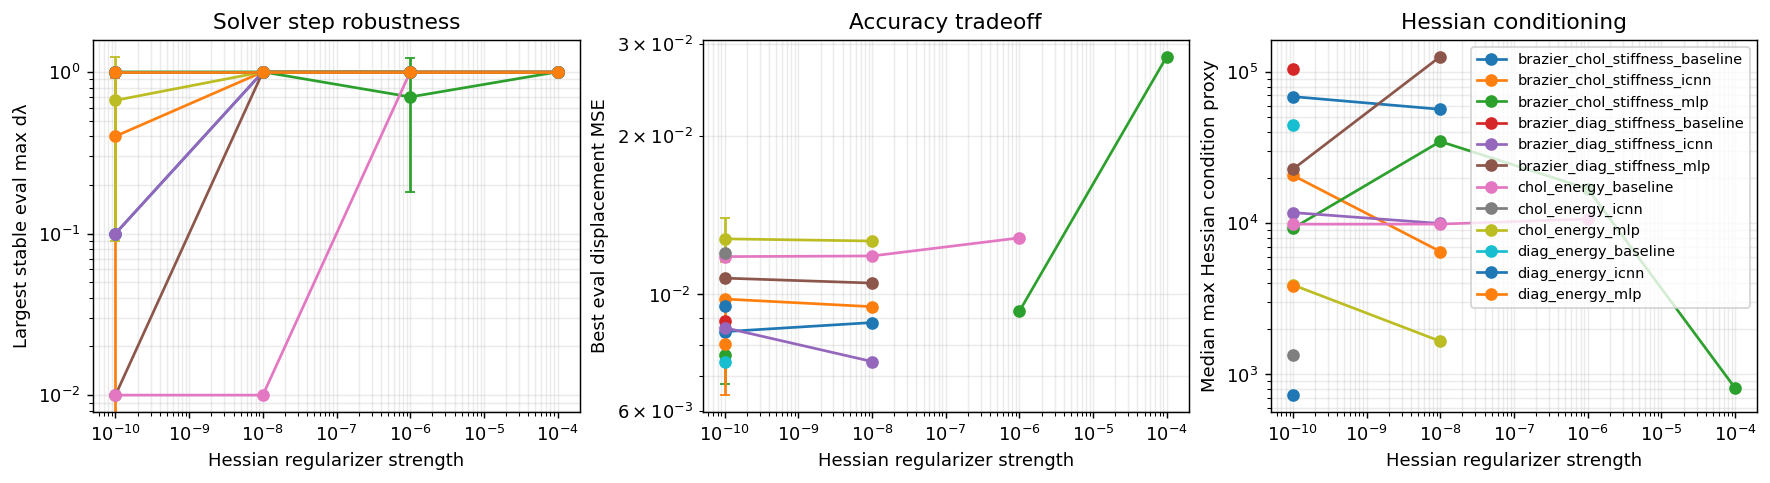

In [5]:
plt.rcParams.update({"font.size": 10, "figure.dpi": 130})
plot_df = summary[summary["train_success"] == True].copy()
plot_df["hreg_plot"] = plot_df["hessian_reg_strength"].replace(0.0, 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True)
for arch, group in plot_df.groupby("arch_name"):
    agg = group.groupby("hreg_plot")["largest_stable_eval_max_dlambda"].agg(["mean", "std"]).reset_index()
    axes[0].errorbar(agg["hreg_plot"], agg["mean"], yerr=agg["std"], marker="o", capsize=3, label=arch)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Hessian regularizer strength"); axes[0].set_ylabel("Largest stable eval max dλ")
axes[0].set_title("Solver step robustness"); axes[0].grid(True, which="both", alpha=0.25)

for arch, group in plot_df.groupby("arch_name"):
    agg = group.groupby("hreg_plot")["best_eval_valid_displacement_mse"].agg(["mean", "std"]).reset_index()
    axes[1].errorbar(agg["hreg_plot"], agg["mean"], yerr=agg["std"], marker="o", capsize=3, label=arch)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Hessian regularizer strength"); axes[1].set_ylabel("Best eval displacement MSE")
axes[1].set_title("Accuracy tradeoff"); axes[1].grid(True, which="both", alpha=0.25)

for arch, group in plot_df.groupby("arch_name"):
    agg = group.groupby("hreg_plot")["kappa_hat"].agg(["median"]).reset_index()
    axes[2].plot(agg["hreg_plot"], agg["median"], marker="o", label=arch)
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel("Hessian regularizer strength"); axes[2].set_ylabel("Median max Hessian condition proxy")
axes[2].set_title("Hessian conditioning"); axes[2].grid(True, which="both", alpha=0.25)
axes[2].legend(loc="best", fontsize=8)

fig.savefig(FIGURE_DIR / "tape_hessian_reg_ablation_panels.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "tape_hessian_reg_ablation_panels.png", bbox_inches="tight")
plt.show()


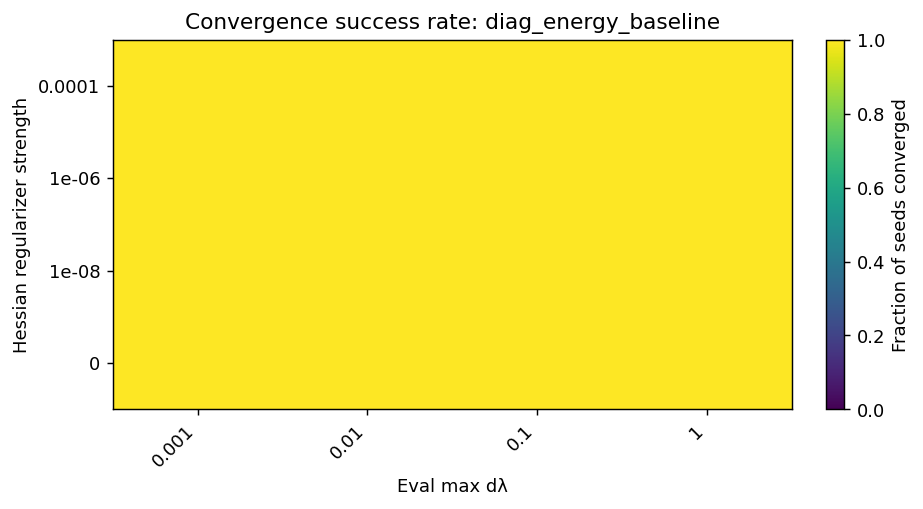

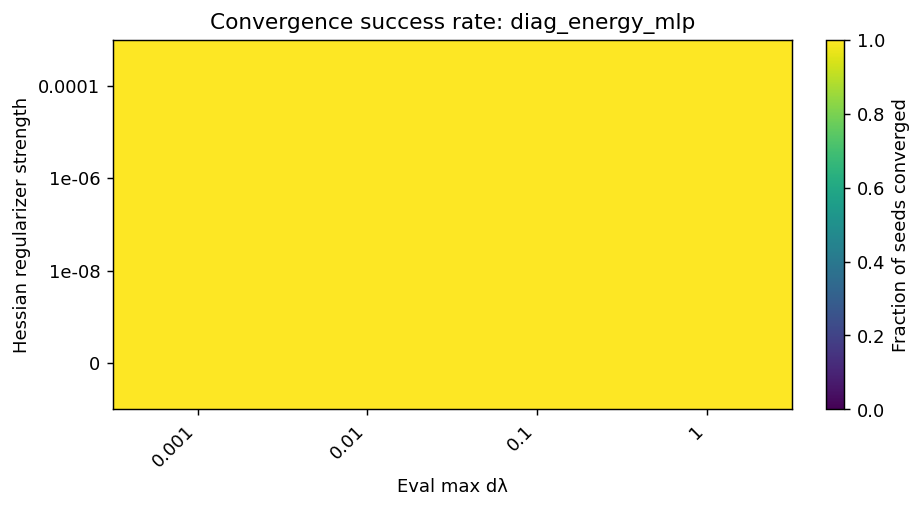

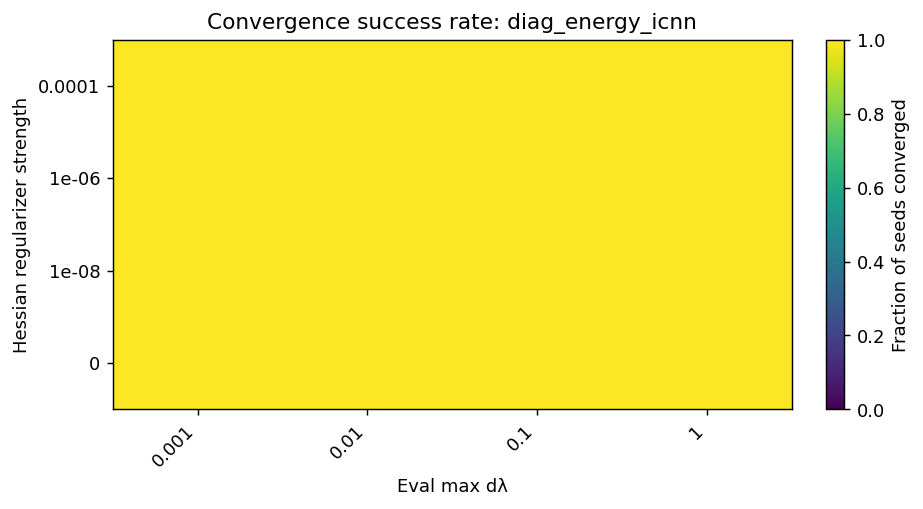

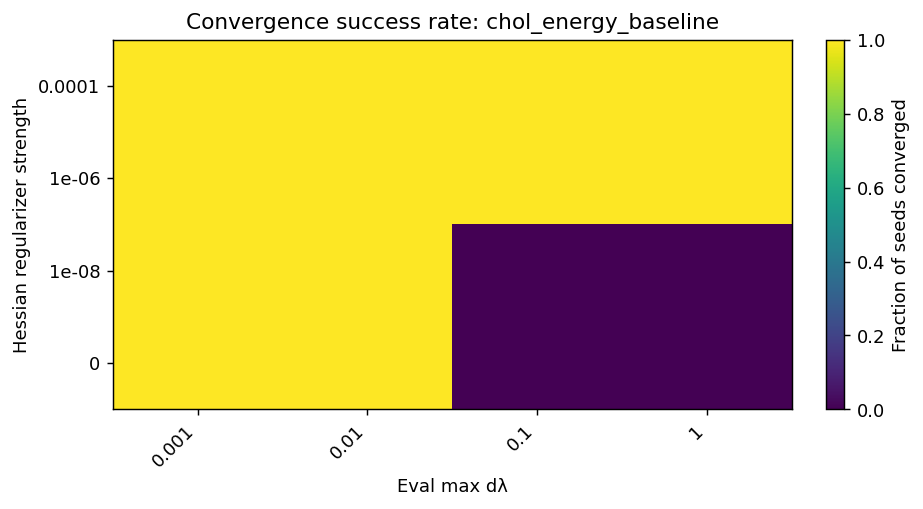

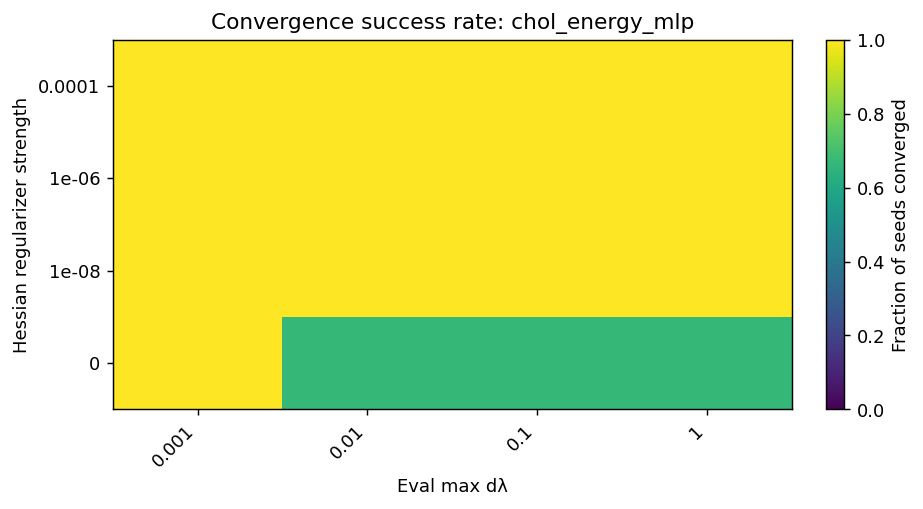

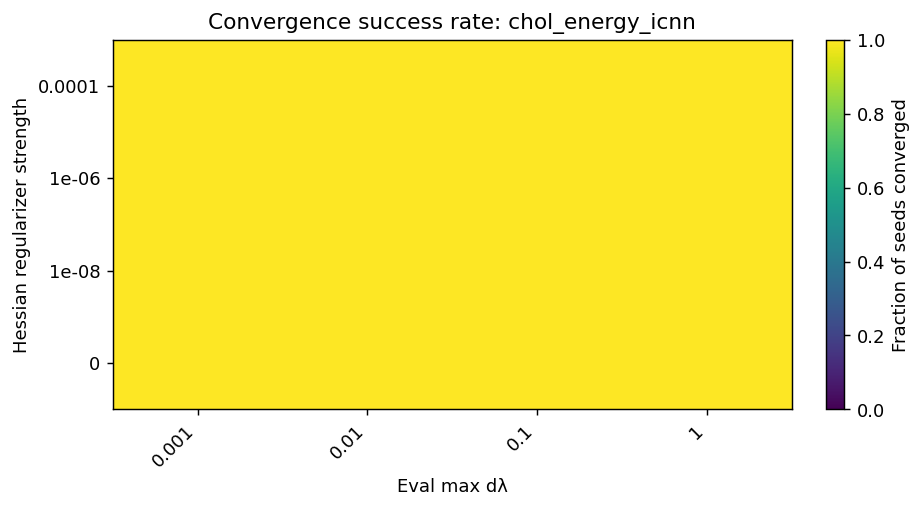

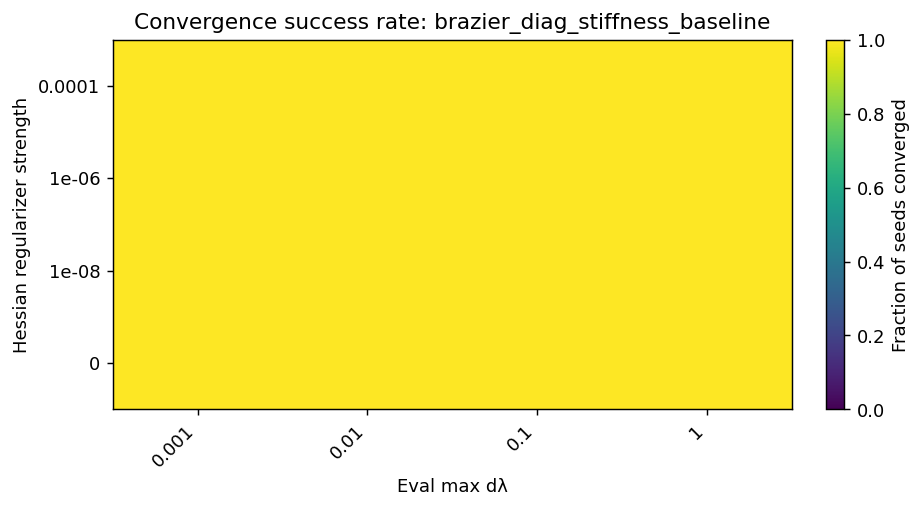

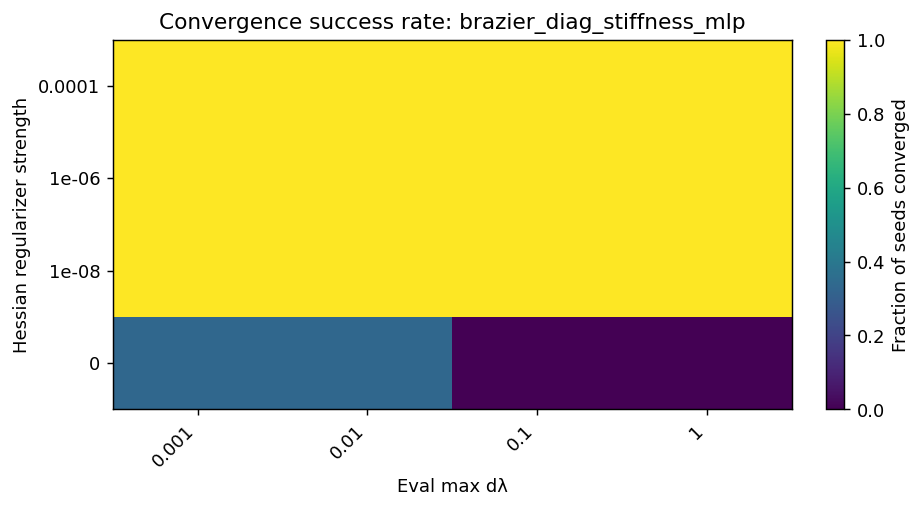

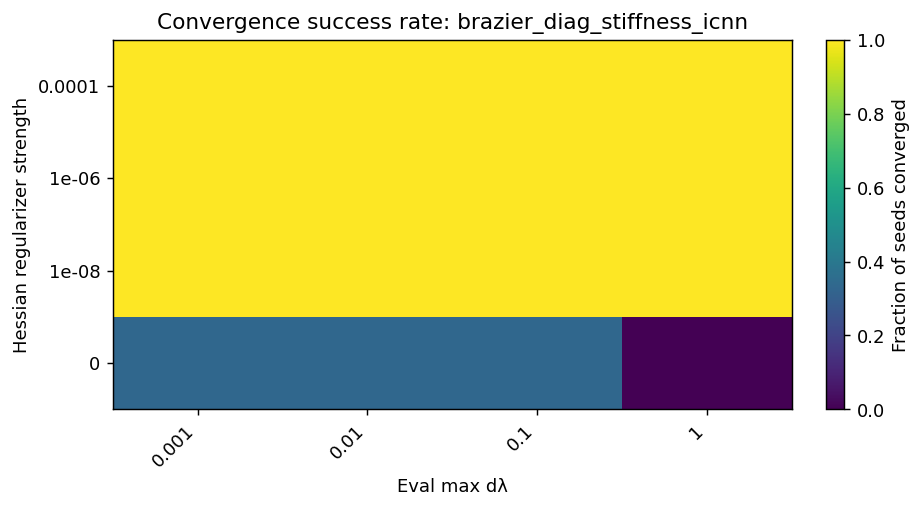

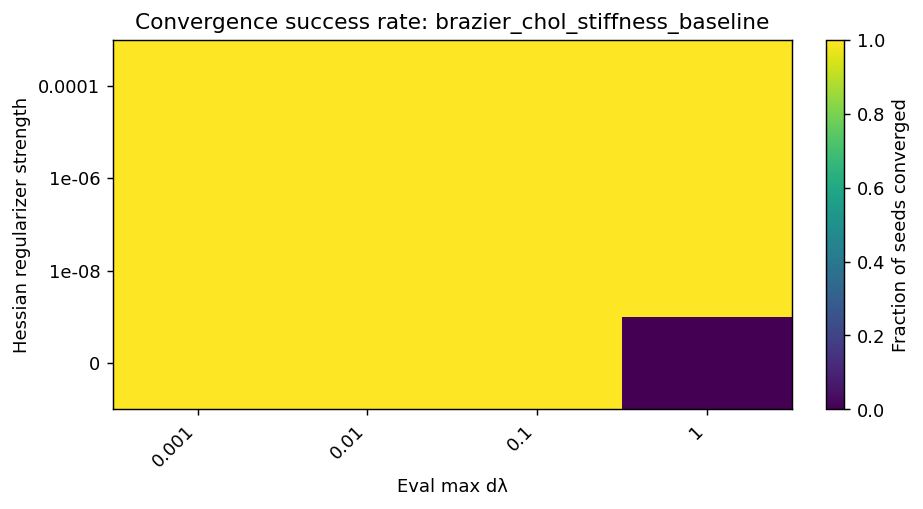

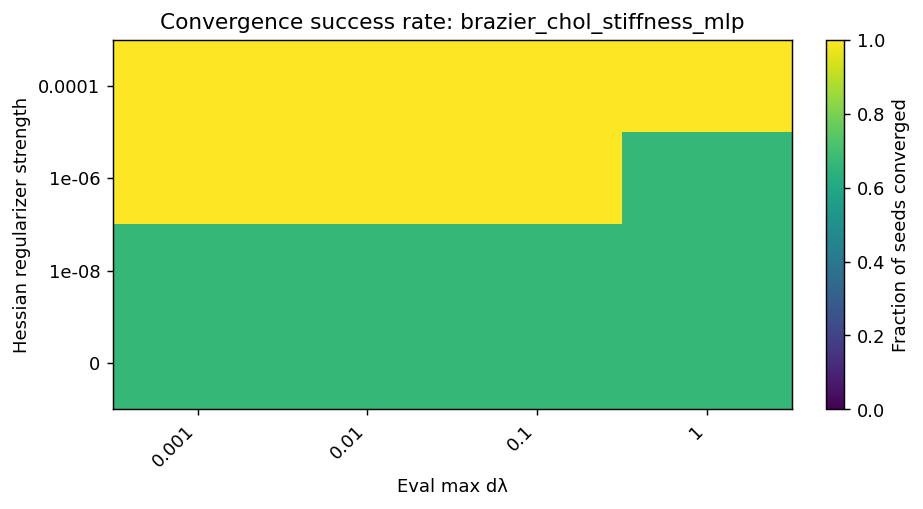

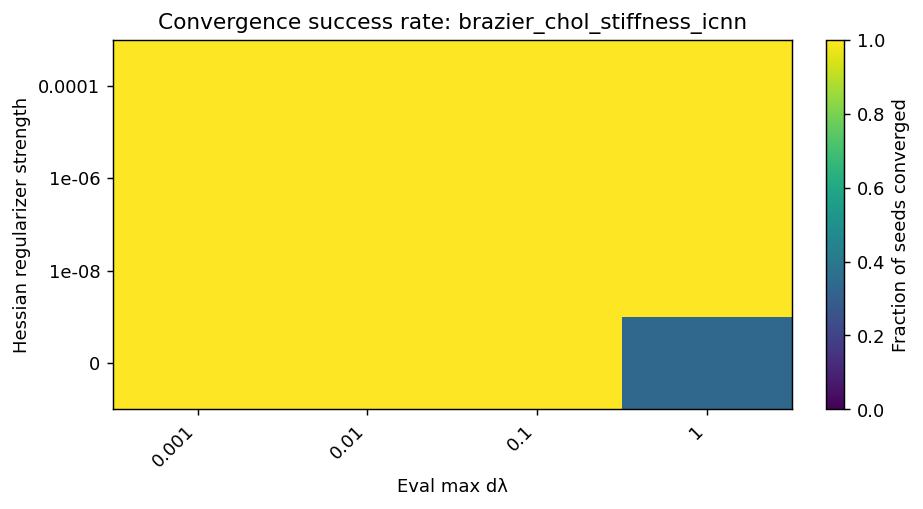

In [6]:
success_rate = (
    eval_df.groupby(["arch_name", "hessian_reg_strength", "eval_max_dlambda"])["success"]
    .mean()
    .reset_index()
)
for arch in SELECTED_ARCHITECTURES:
    arch_df = success_rate[success_rate["arch_name"] == arch]
    if arch_df.empty:
        continue
    heat = arch_df.pivot(index="hessian_reg_strength", columns="eval_max_dlambda", values="success")
    fig, ax = plt.subplots(figsize=(7.0, 3.8), constrained_layout=True)
    im = ax.imshow(heat.values, aspect="auto", origin="lower", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels([f"{v:g}" for v in heat.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels([f"{v:g}" for v in heat.index])
    ax.set_xlabel("Eval max dλ")
    ax.set_ylabel("Hessian regularizer strength")
    ax.set_title(f"Convergence success rate: {arch}")
    fig.colorbar(im, ax=ax, label="Fraction of seeds converged")
    fig.savefig(FIGURE_DIR / f"tape_success_heatmap_{arch}.pdf", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"tape_success_heatmap_{arch}.png", bbox_inches="tight")
    plt.show()
